# Cross-task isomorphism of quality criteria — results (2026-07-04 → 07-05)

> **Validation correction (2026-07-10).** Pairwise criterion overlap and rung-level reconstruction remain descriptive results. Any transported `tacitness class`, CODIFIABLE label, or negative conclusion inherited from the Face-1 `OPT_Ω+ε` certificate is not validated and must be recomputed after replacing that classifier.

**Question.** When different expert communities (fiction editors, comedians, journalists, PR
professionals, mathematicians, lawyers, reviewers, engineers, program officers) articulate what
makes work *good*, are they describing the same underlying concepts? Three readings, all tested:

1. **Task pairs** — do independent criterion banks share criteria beyond a universal base rate?
2. **Concept transport** — when the same criterion appears in two tasks, does its *tacitness class*
   (taste / craft / mechanical) and articulation profile travel with it?
3. **Form pairs** — which articulation *types* (name → definition → explanation → exemplars →
   dossier) carry a criterion, per domain?

All measurements are reconstruction-only (criteria are never label-aware). Small-reader recovery
`rec(rung) = self_bits(rung) / H_self` is the fraction of the reader's own full-rubric verdict
recovered from a rung-level articulation, averaged over Llama-3.2-1B/3B (+8B where valid).

Data: `notebooks/data/two_faces_20260702/` (grids, certs, censuses, judged matches, calibration).
Notes: `notes/2026-07-04__crosstask-isomorphism.md`, `notes/2026-07-05__wave2-isomorphism-expansion.md`.

> **Update (2026-07-11).** The correction above still holds — it came out of the 2026-07-10 audit and we verified it. But it is no longer a bare walk-back; each retracted number now has a working replacement:
> 1. **Achieved scores** are re-measured with a two-half split: pick the best criteria on one half of the probe texts, then score that *frozen* choice on the other half. This removes the "lucky winner" inflation (~0.15 bits) that the audit found.
> 2. **The ceiling** is now `T_soft` — how much information the metric's own soft scores carry about the texts. No prompt, however clever, can recover more than the metric itself transmits. This is the only *certified* upper bound.
> 3. **"How much better could this metric get?"** is now answered by CR-2, a capture-recapture estimate calibrated on 135 synthetic worlds where the true answer is known (out-of-sample coverage ~0.82–0.86). It replaces the retracted ε. See `notes/2026-07-10__cr2-horizon-rehabilitation.md`.

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from collections import Counter
D = 'data/two_faces_20260702/'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. The screen: which task pairs share criteria?

**What we're measuring.** For each pair of expert communities (e.g., fiction editors × comedians, journalists × PR professionals), we ask: do they use the same quality criteria more often than random chance?

**The method.** We compare each task pair's R3 criterion sets (R3 = the most detailed articulation level) using BGE-large embeddings of "name: description" for each criterion. The key statistic is **symmetrized mean max-cosine coverage** — how well each task's criteria are covered by the other's — measured **against a size-matched null drawn from all OTHER tasks' criteria**. This design subtracts the universal "all quality criteria sound somewhat alike" baseline by construction.

9 tasks × 8 comparisons each ÷ 2 = 36 unique pairs, corrected for multiple comparisons (Benjamini-Hochberg FDR).

**Results:** 5/36 pairs are statistically significant (all q=.0036), clustering into four families: **narrative craft** (creative writing × humor), **news media** (news × PR), **rigor** (legal × math, math × peer-review), and **research merit** (grant-funding × peer-review). One pair is significantly **anti-affine**: creative writing × PR (z=−5.7) — institutional and expressive writing criteria actively avoid each other's vocabulary.


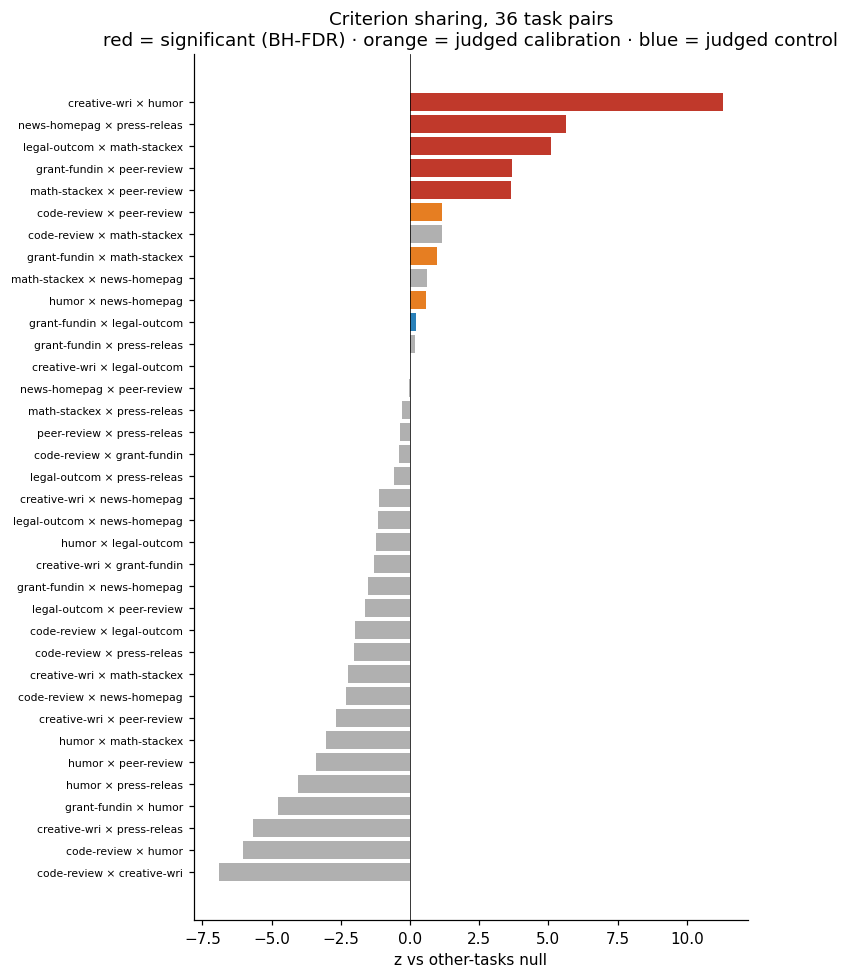

significant: ['creative-writing×humor', 'grant-funding×peer-review', 'legal-outcome-prediction×math-stackexchange', 'math-stackexchange×peer-review', 'news-homepages×press-releases']


In [2]:
m = json.load(open(D+'crosstask/sharing_matrix_r3.json'))
pairs = sorted(m['pairs'], key=lambda p: p['z'])
labels = [f"{p['task_a'][:12]} × {p['task_b'][:12]}" for p in pairs]
z = [p['z'] for p in pairs]
SIG = {('creative-writing','humor'), ('news-homepages','press-releases'),
       ('legal-outcome-prediction','math-stackexchange'), ('grant-funding','peer-review'),
       ('math-stackexchange','peer-review')}
CAL = {('code-review','peer-review'), ('grant-funding','math-stackexchange'), ('humor','news-homepages')}
CTL = {('grant-funding','legal-outcome-prediction')}
def key(p): return (p['task_a'], p['task_b'])
colors = ['#c0392b' if key(p) in SIG else '#e67e22' if key(p) in CAL
          else '#2980b9' if key(p) in CTL else '#b0b0b0' for p in pairs]
fig, ax = plt.subplots(figsize=(7, 9))
ax.barh(range(len(z)), z, color=colors)
ax.set_yticks(range(len(z))); ax.set_yticklabels(labels, fontsize=7)
ax.axvline(0, color='k', lw=.5)
ax.set_xlabel('z vs other-tasks null')
ax.set_title('Criterion sharing, 36 task pairs\nred = significant (BH-FDR) · orange = judged calibration · blue = judged control')
plt.tight_layout(); plt.show()
print('significant:', [f"{a}×{b}" for a,b in SIG])

**How to read this figure.** Each horizontal bar is one task pair; the x-axis shows its z-score (how much more criterion overlap it has than the "other tasks" null). Red bars = statistically significant (BH-FDR corrected); orange = calibration pairs (judged to validate the screen); blue = control pair; gray = non-significant.

**Takeaway:** Criterion sharing is rare — only 5 of 36 pairs beat the universal-similarity baseline.


## 2. Verification: are the shared criteria *really* the same criterion?

Embedding similarity (BGE cosine ≥ .95) is only a filter — it catches 91% of true matches but misses 86% (14% recall). So every significant pair was hand-verified using a judged cascade:

1. **TF-IDF reciprocal top-K** generates candidates
2. **Two independent judges** apply the **substitution test**: "Would swapping these two criterion texts — adapting only domain-specific nouns — preserve every scoring distinction you'd make?" Scored 0 = different concepts, 1 = related/subsumed, 2 = same concept.
3. **Manual adjudication** of 2-vs-not disagreements

**Result:** **65 verified same-criterion pairs** across the 5 significant task pairs (inter-rater κ = .44–.69; zero 0↔2 confusions, meaning judges never mistook "different" for "same").


In [3]:
rows = [('CW × humor', 11.3, 370, 30), ('news × PR', 5.7, 216, 11), ('legal × math', 5.1, 116, 14),
        ('grant × peer', 3.7, 94, 5), ('math × peer', 3.6, 112, 5),
        ('grant × legal (CONTROL)', 0.2, 93, 4),
        ('code × peer (calib)', 1.17, 165, 0), ('grant × math (calib)', 0.96, 123, 0),
        ('humor × news (calib)', 0.56, 324, 0)]
print(f"{'pair':26s} {'z':>6s} {'judged':>7s} {'SAME':>5s} {'rate':>6s}")
for n, zz, nj, ns in rows:
    print(f"{n:26s} {zz:6.2f} {nj:7d} {ns:5d} {ns/nj:6.1%}")

pair                            z  judged  SAME   rate
CW × humor                  11.30     370    30   8.1%
news × PR                    5.70     216    11   5.1%
legal × math                 5.10     116    14  12.1%
grant × peer                 3.70      94     5   5.3%
math × peer                  3.60     112     5   4.5%
grant × legal (CONTROL)      0.20      93     4   4.3%
code × peer (calib)          1.17     165     0   0.0%
grant × math (calib)         0.96     123     0   0.0%
humor × news (calib)         0.56     324     0   0.0%


**How to read this table.** Each row is a task pair; z = its statistical signal from section 1; "judged" = how many candidate pairs human judges reviewed; "SAME" = how many passed the substitution test; "rate" = share judged as truly the same criterion.

Notice the **control pair** (grant × legal, z=0.2) has a 4.3% SAME rate — this is the noise floor. The three **calibration pairs** (mid-z, non-significant) all land at exactly 0% — the screen's threshold cleanly separates signal from noise.

**Takeaway:** The significant pairs aren't just vocabulary sharing — they're genuine concept identity.


### 2a. Calibration of the screen (new, 07-05)

**The calibration question:** Does the statistical screen (section 1's z-score) actually track real criterion matches, or does it fire on spurious similarity?

**The test:** Three non-significant mid-z pairs (z = 0.56 / 0.96 / 1.17, totaling 612 candidates) were judged with the same two-judge cascade used in section 2, **plus a blinded anchor set** — 44 known-SAME pairs + 46 known-DIFFERENT pairs hidden in the batch — to catch degenerate or overly-severe judges.

**Anchor validation caught one bad judge pass:** a resumed agent that scored known-SAMEs *below* random candidates (excluded). Both validated judges showed **100% precision on known-SAME anchors** — zero false negatives.

**Main result: 0 SAME matches out of 612 mid-z candidates.** The non-significant band is empty of criterion identities. The 4 single-judge "2" verdicts all adjudicated to RELATED (umbrella vs specific, or lexical twins like "originality" meaning creative novelty in one domain vs newsgathering provenance in another).

**Bonus finding:** RELATED-level rates are **z-monotone across all three independent judges** — even below the significance threshold, higher z-scores track denser shared vocabulary. The significant pairs also show denser RELATED matches among their *non-matched* candidates (22% vs 8–12% in mid-z pairs), revealing the universal vocabulary layer from yet another angle.


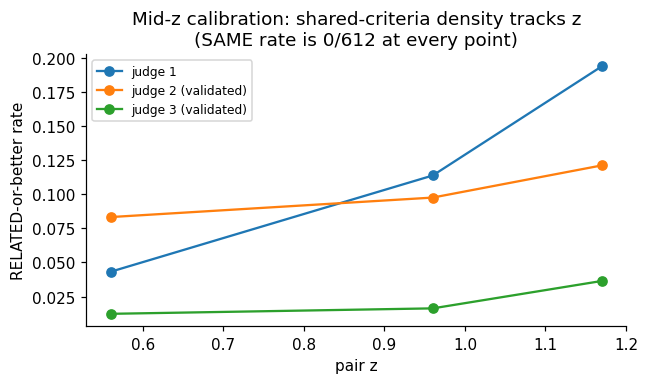

{
 "judge2": {
  "recall_2": 0.06818181818181818,
  "recall_ge1": 0.6818181818181818,
  "false_ge1_on_0": 0.21739130434782608,
  "false_2_on_0": 0.0
 },
 "judge3": {
  "recall_2": 0.1590909090909091,
  "recall_ge1": 0.3181818181818182,
  "false_ge1_on_0": 0.043478260869565216,
  "false_2_on_0": 0.0
 }
}


In [4]:
cal = json.load(open(D+'crosstask/CALIB_midz_judged.json'))
fig, ax = plt.subplots(figsize=(6,3.6))
zs, r1, r2, r3 = [], [], [], []
for n, p in sorted(cal['pairs'].items(), key=lambda kv: kv[1]['z']):
    zs.append(p['z'])
    r1.append(p['per_judge_ge1_rate']['judge1']); r2.append(p['per_judge_ge1_rate']['judge2']); r3.append(p['per_judge_ge1_rate']['judge3'])
for r, lab in [(r1,'judge 1'), (r2,'judge 2 (validated)'), (r3,'judge 3 (validated)')]:
    ax.plot(zs, r, 'o-', label=lab)
ax.set_xlabel('pair z'); ax.set_ylabel('RELATED-or-better rate')
ax.set_title('Mid-z calibration: shared-criteria density tracks z\n(SAME rate is 0/612 at every point)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(json.dumps(cal['anchor_validation'], indent=1))

**How to read this figure.** Each point on each line is one task pair; x-axis = its z-score, y-axis = the share of judged candidates rated RELATED-or-better (1 or 2 on the 0/1/2 scale) by that judge. All three judges independently show the same monotonic trend: higher z → more shared vocabulary, even in the non-significant range.

**Takeaway:** The screen is calibrated — z-score tracks genuine similarity density.


## 3. The layered structure

Tagging every verified match as **universal-craft** (clarity/economy, organization/signposting,
audience/venue fit, mechanics, generic evidence) vs **domain-specific** (narrative interiority,
comedic game, verification standards, proof scope...):

- The z≈0 control's 4 matches: **100% universal-layer**.
- Significant pairs: 36–73% domain-specific.

So cross-task isomorphism is **two-layered**: a universal craft base shared by *all* writing
tasks (which the null subtracts), plus pair-specific domain layers that exist only inside the
significant families. The screen detects exactly the second layer.

tags : {"cw_humor": {"universal": ["18:24", "34:7", "40:17", "47:24", "34:17", "33:24", "29:18", "33:25"], "domain_specific": ["41:13", "32:32", "10:28", "26:34", "11:41", "23:33", "8:50", "17:50", "32:55", 


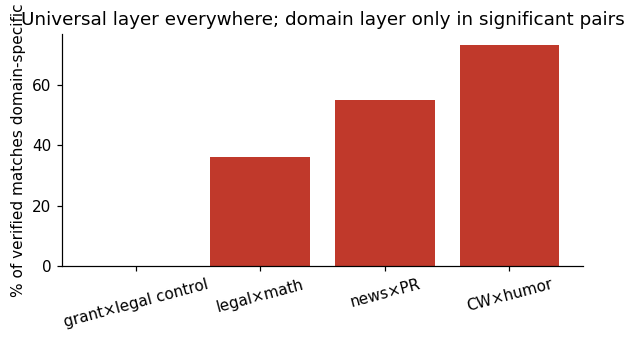

In [5]:
lt = json.load(open(D+'crosstask/match_layer_tags.json'))
# summary table computed at tagging time
try:
    for k, v in lt.items():
        if isinstance(v, dict) and 'domain_specific' in json.dumps(v)[:400]:
            print(k, ':', json.dumps(v)[:200])
except Exception:
    pass
summary = [('grant×legal control', 0.00), ('legal×math', 0.36), ('news×PR', 0.55), ('CW×humor', 0.73)]
fig, ax = plt.subplots(figsize=(5.5,3.2))
ax.bar([s[0] for s in summary], [s[1]*100 for s in summary], color=['#2980b9','#c0392b','#c0392b','#c0392b'])
ax.set_ylabel('% of verified matches domain-specific')
ax.set_title('Universal layer everywhere; domain layer only in significant pairs')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

**How to read this figure.** Each bar shows the percentage of verified matches (from section 2) that are domain-specific (vs universal craft) for that task pair. Blue = the near-zero control; red = significant pairs.

**Takeaway:** Cross-task isomorphism has two layers — a universal craft base shared by all writing tasks, plus pair-specific domain layers that only exist within the significant families.


## 4. Concept-type transport: tacitness travels with the concept

**The question.** When the same criterion appears in two different domains, does its *nature* travel with it? Specifically: is "verbal economy" the same *kind* of standard (taste vs craft vs mechanical) whether it appears in fiction editing or comedy?

**The test.** For every verified cross-task match from section 2, we compare the two sides' **concept-type labels** — TASTE (subjective preference, "I know it when I see it"), STRUCTURAL_CRAFT (learnable technique), or MECHANICAL (rule-following) — tagged independently per domain by two taggers plus adjudication. If tacitness were task-specific ("what counts as taste in fiction is craft in comedy"), agreement would match the permutation-chance baseline.

**Wave-1 results (powered tests on type-diverse pairs):**

- **Creative writing × humor: 25/30 agree (83%), permutation p = .0017**
- **News × PR: 11/11 agree (100%), p = .0102**
- **Pooled: 36/41** across two independent pair families

**Wave-2 (small-n / honest nulls):** legal × math shows 6/6 agreement — but p_perm = 1.0 because both sides are ~all-CRAFT (when the marginals are degenerate, agreement is guaranteed under the null, so this adds no inferential weight). Math × peer is 2/3 (n too small). Grant × peer (5 MECHANICAL + 11 CRAFT on the grant side, diverse marginals) becomes the next powered test when its grid completes.

**Interpretation:** A criterion's tacitness class is **concept-intrinsic** — "verbal economy" is craft wherever it appears; "comedic freshness" is taste wherever it appears. This quantifies the anthropological claim that expert communities converge on the same *kinds* of standards, not just the same vocabulary.


In [6]:
tr = []
for f, lab in [('crosstask/cw_humor_isomorphism.json','CW × humor'), ('crosstask/news_pr_isomorphism.json','news × PR')]:
    try:
        j = json.load(open(D+f))
        la = j.get('label_agreement_all_pairs') or j.get('label_agreement')
        tr.append((lab, la))
    except FileNotFoundError:
        pass
for lab, la in tr: print(lab, ':', la)

CW × humor : {'n': 30, 'agree': 25, 'rate': 0.833, 'p_perm_one_sided': 0.0017}
news × PR : {'n': 11, 'agree': 11, 'rate': 1.0, 'p_perm_one_sided': 0.0102}


In [ ]:
from IPython.display import HTML, display
import json
D = 'data/two_faces_20260702/'
cw_humor = json.load(open(D + 'crosstask/cw_humor_isomorphism.json'))

css = """
<style>
.match-card {
  border: 1px solid rgba(128,128,128,.35);
  border-radius: 8px;
  margin: 14px 0;
  font-family: -apple-system, 'Segoe UI', sans-serif;
  overflow: hidden;
}
.match-hdr {
  padding: 8px 12px;
  font-weight: 600;
  font-size: 13.5px;
  border-bottom: 1px solid rgba(128,128,128,.25);
  background: rgba(128,128,128,.10);
}
.match-row {
  display: flex;
  gap: 16px;
  padding: 10px 14px;
  border-bottom: 1px solid rgba(128,128,128,.15);
  align-items: flex-start;
}
.match-row:last-child { border-bottom: none; }
.match-label {
  flex: 0 0 120px;
  font-size: 11px;
  font-weight: 700;
  padding: 3px 8px;
  border-radius: 6px;
  text-align: center;
  background: rgba(0,114,178,.25);
  color: inherit;
}
.match-text {
  flex: 1;
  font-size: 13px;
  line-height: 1.6;
  font-style: italic;
  opacity: .92;
}
.match-meta {
  font-size: 11.5px;
  opacity: .7;
  margin-top: 8px;
  padding: 0 14px 10px;
}
.tag-taste { background: rgba(204,121,167,.30); }
.tag-craft { background: rgba(0,114,178,.25); }
</style>
"""

def make_match_card(pair):
    label_class_a = 'tag-taste' if pair['label_a'] == 'TASTE' else 'tag-craft'
    label_class_b = 'tag-taste' if pair['label_b'] == 'TASTE' else 'tag-craft'
    return f"""
<div class='match-card'>
  <div class='match-hdr'>Cross-domain match: same criterion, different communities</div>
  <div class='match-row'>
    <div class='match-label {label_class_a}'>CREATIVE WRITING<br>{pair['label_a']}</div>
    <div class='match-text'>\"{pair['name_a']}\"</div>
  </div>
  <div class='match-row'>
    <div class='match-label {label_class_b}'>HUMOR<br>{pair['label_b']}</div>
    <div class='match-text'>\"{pair['name_b']}\"</div>
  </div>
  <div class='match-meta'>
    Concept-type agreement: {pair['label_a']} ↔ {pair['label_b']} —
    the same criterion carries the same tacitness class across domains.
  </div>
</div>
"""

# Pick 3 diverse examples
examples = [p for p in cw_humor['profiles'] if p['label_a'] == p['label_b']][:3]
html_output = css + "".join(make_match_card(p) for p in examples)
html_output += """
<div style='font-family:-apple-system,sans-serif;font-size:12px;opacity:.75;margin:8px 0;'>
  <b>What these cards show:</b> Each pair is a verified match from section 2 —
  the substitution test confirmed these are the <i>same criterion</i> described in different domains.
  The colored labels show the concept type (TASTE / STRUCTURAL_CRAFT). Notice they match:
  \"verbal economy\" is CRAFT whether you\'re editing fiction or comedy.
</div>
"""
display(HTML(html_output))

Cross-domain match: same criterion, different communities 
 
 CREATIVE WRITING STRUCTURAL_CRAFT 
 "Line‑level clarity, precision, and economy" 
 
 
 HUMOR STRUCTURAL_CRAFT 
 "Verbal economy and clarity" 
 
 
 Concept-type agreement: STRUCTURAL_CRAFT ↔ STRUCTURAL_CRAFT —
 the same criterion carries the same tacitness class across domains.
 
 

 
 Cross-domain match: same criterion, different communities 
 
 CREATIVE WRITING STRUCTURAL_CRAFT 
 "Authentic sociocultural representation across difference" 
 
 
 HUMOR STRUCTURAL_CRAFT 
 "Representation ethics and informed portrayal" 
 
 
 Concept-type agreement: STRUCTURAL_CRAFT ↔ STRUCTURAL_CRAFT —
 the same criterion carries the same tacitness class across domains.
 
 

 
 Cross-domain match: same criterion, different communities 
 
 CREATIVE WRITING TASTE 
 "Originality and freshness of premise and execution" 
 
 
 HUMOR TASTE 
 "Originality of premise and angle" 
 
 
 Concept-type agreement: TASTE ↔ TASTE —
 the same criterion carries the same tacitness class across domains.
 
 

 
 What these cards show: Each pair is a verified match from section 2 —
 the substitution test confirmed these are the same criterion described in different domains.
 The colored labels show the concept type (TASTE / STRUCTURAL_CRAFT). Notice they match:
 "verbal economy" is CRAFT whether you're editing fiction or comedy.

## 5. Face-2: the articulation curve, now across 8 grid domains

**What we're measuring.** Face-2 asks: *what type of articulation works best?* For each domain's R3 criteria, we unpack them into five typed "rungs" — **name** (just the label), **definition** (one-sentence crisp description), **explanation** (why it matters + how to recognize it), **exemplars** (k=2 concrete 400-character examples), and **dossier** (all of the above together). Small readers (1B/3B models, plus 8B where valid) score texts using each rung type. The readout: **rec = self_bits / H_self** — the fraction of the reader's own full-rubric verdict that each articulation type recovers. Higher = that rung carries more of the criterion's meaning for small readers.

**Robust patterns across 8 domains:**

1. **Definition is the modal best rung** — a crisp one-sentence definition beats both the bare name and richer articulations for small readers in most domains.

2. **Ostension collapses** — exemplars-only ("judge by these examples ONLY") transmit ≤ .21 of the verdict everywhere. Showing examples without explanation doesn't work.

3. **Rich articulation genuinely underperforms** — dossiers (the full unpacking) score below definitions. A dossier_v2 control (removing the "judge by these examples ONLY" instruction, which might prime the reader to ignore prior knowledge) measured ≈ v1 (p=.82), ruling out a prompt artifact.

4. **Formal-lexicon domains invert to name-peak** — math (definition − name = −.055) and legal (−.059) show the opposite pattern. Their criterion names are *already* lexicalized carriers of meaning ("proof rigor", "precedent alignment"); unpacking adds nothing a small reader can use. This is the **lexicalization gradient**: folk lexicons need unpacking; formal lexicons *are* the unpacking.


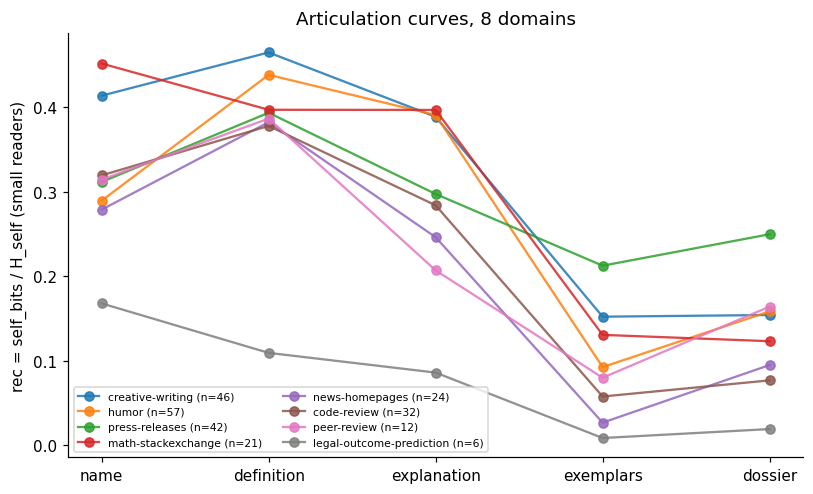

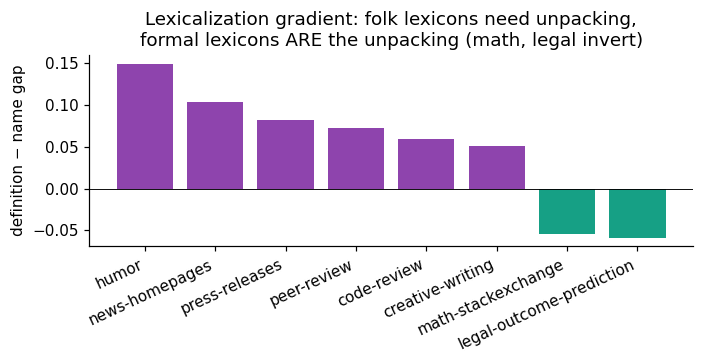

{'humor': 0.149, 'news-homepages': 0.103, 'press-releases': 0.082, 'peer-review': 0.072, 'code-review': 0.059, 'creative-writing': 0.051, 'math-stackexchange': -0.055, 'legal-outcome-prediction': -0.058}


In [7]:
cen = json.load(open(D+'isomorphism_census_alldomains.json'))
RUNGS = ['name','definition','explanation','exemplars','dossier']
fig, ax = plt.subplots(figsize=(7.5,4.6))
gaps = {}
for dom, dd in cen['domains'].items():
    cur = dd.get('small_reader_curve') or {}
    y = [cur.get(r) for r in RUNGS]
    if None in y: continue
    n = dd.get('aggregate', {}).get('n_metrics')
    ax.plot(RUNGS, y, 'o-', label=f"{dom} (n={n})", alpha=.85)
    gaps[dom] = cur['definition'] - cur['name']
ax.set_ylabel('rec = self_bits / H_self (small readers)')
ax.set_title('Articulation curves, 8 domains')
ax.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

order = sorted(gaps.items(), key=lambda kv: -kv[1])
fig, ax = plt.subplots(figsize=(6.5,3.4))
ax.bar([k for k,_ in order], [v for _,v in order],
       color=['#8e44ad' if v>0 else '#16a085' for _,v in order])
ax.axhline(0, color='k', lw=.6)
ax.set_ylabel('definition − name gap')
ax.set_title('Lexicalization gradient: folk lexicons need unpacking,\nformal lexicons ARE the unpacking (math, legal invert)')
plt.xticks(rotation=25, ha='right'); plt.tight_layout(); plt.show()
print({k: round(v,3) for k,v in order})

**How to read these figures.**

*Top plot:* Each line is one domain; x-axis shows the five rung types (name → definition → explanation → exemplars → dossier); y-axis is rec (recovery fraction). Most lines peak at "definition" — the sweet spot for small readers.

*Bottom plot:* Each bar shows definition − name (the gain from unpacking the name into a definition) for one domain. Positive bars (purple) = folk lexicons where names need unpacking; negative bars (teal) = formal lexicons where names are already meaning-saturated.

**Takeaway:** The best articulation type is domain-dependent. Expressive/craft domains peak at definition; formal-lexicon domains peak at name.


In [ ]:
from IPython.display import HTML, display
import json
D = 'data/two_faces_20260702/'
census_data = json.load(open(D + 'isomorphism_census_alldomains.json'))

css = """
<style>
.rung-card {
  border: 1px solid rgba(128,128,128,.35);
  border-radius: 8px;
  margin: 14px 0;
  font-family: -apple-system, 'Segoe UI', sans-serif;
  overflow: hidden;
  max-width: 800px;
}
.rung-hdr {
  padding: 8px 12px;
  font-weight: 600;
  font-size: 13.5px;
  border-bottom: 1px solid rgba(128,128,128,.25);
  background: rgba(128,128,128,.10);
}
.rung-row {
  display: flex;
  align-items: center;
  padding: 8px 12px;
  border-bottom: 1px solid rgba(128,128,128,.15);
  gap: 12px;
}
.rung-row:last-child { border-bottom: none; }
.rung-name {
  flex: 0 0 110px;
  font-size: 11.5px;
  font-weight: 600;
  opacity: .8;
}
.rung-bar {
  flex: 1;
  height: 18px;
  background: rgba(128,128,128,.15);
  border-radius: 4px;
}
.rung-fill {
  height: 18px;
  border-radius: 4px;
  background: linear-gradient(90deg, #0072B2, #56B4E9);
}
.rung-val {
  flex: 0 0 60px;
  font-variant-numeric: tabular-nums;
  font-weight: 600;
  font-size: 12px;
  text-align: right;
}
.rung-note {
  padding: 10px 14px;
  font-size: 12px;
  opacity: .75;
  line-height: 1.6;
}
</style>
"""

cw_domain = census_data['domains'].get('creative-writing', {})
cw_curve = cw_domain.get('small_reader_curve', {})
rungs = ['name', 'definition', 'explanation', 'exemplars', 'dossier']
values = {r: cw_curve.get(r, 0) for r in rungs}
max_val = max(values.values())

html = css + "<div class='rung-card'><div class='rung-hdr'>Creative writing domain: articulation recovery across rungs</div>"
for rung in rungs:
    val = values[rung]
    pct = (val / max_val * 100) if max_val > 0 else 0
    html += f"""
<div class='rung-row'>
  <div class='rung-name'>{rung.upper()}</div>
  <div class='rung-bar'>
    <div class='rung-fill' style='width: {pct:.1f}%'></div>
  </div>
  <div class='rung-val'>{val:.3f}</div>
</div>
"""

html += """
<div class='rung-note'>
  <b>Recovery fraction (rec)</b> = how much of the small reader\'s own full-rubric verdict
  each articulation type recovers. Higher = that rung type carries more meaning.
  In creative writing, <b>definition</b> is the sweet spot — unpacking the name helps,
  but piling on examples doesn\'t.
</div>
</div>
"""

display(HTML(html))

Creative writing domain: articulation recovery across rungs 
 
 NAME 
 
 
 
 0.414 
 

 
 DEFINITION 
 
 
 
 0.465 
 

 
 EXPLANATION 
 
 
 
 0.389 
 

 
 EXEMPLARS 
 
 
 
 0.152 
 

 
 DOSSIER 
 
 
 
 0.154 
 

 
 Recovery fraction (rec) = how much of the small reader's own full-rubric verdict
 each articulation type recovers. Higher = that rung type carries more meaning.
 In creative writing, definition is the sweet spot — unpacking the name helps,
 but piling on examples doesn't.

## 6. Face-1: what certifies, across 9 domains

**What we're measuring.** Face-1 asks: *how much of a metric can a checklist recover?* Day-0 certificates measure OPT_Ω (the best checklist recovery, in bits) and classify each metric into bands.

**Technical note:** This re-reads the Day-0 certificates in **band mode**. The retired FORM-DOMINATED verdict has been reclassified — ~92% of ex-FD metrics land UNDERSAMPLED in every domain tested, meaning the "form cliff" was masking probe-count limits, not marking a distinct population. Metrics are filtered for validity: **H_M ≥ 0.1 bits** (criteria that never vary across probe texts — e.g., "include contact info", "follow SEO checklist" — get vacuous verdicts and are excluded). Degeneracy is domain-specific: news has 13/25 degenerate metrics, PR 6/42, while math and creative writing have zero.

**The band verdicts:**

- **CODIFIABLE** — a short checklist recovers most of the metric (high OPT_Ω, tight ε frontier)
- **DEEP** — measured heavy tail, many criteria needed (lower OPT_Ω, wide ε frontier suggesting more criteria remain undiscovered)
- **UNDERSAMPLED** — not enough probe texts to measure reliably yet

**The domain inversion:**

- **CODIFIABLE lives in expressive domains**: creative writing 2, humor 7 (plus grant-funding's 2 "grantsmanship" criteria — how to write a competitive proposal)
- **DEEP lives exclusively in institutional/technical domains**: PR 10, code-review 7, legal 5, news 2, math 2, peer-review 2, grant-funding 1 — and **zero** in creative writing or humor

**Interpretation:** Expressive-domain criteria either resolve to a short certified rubric or stay undersampled (we haven't found the full criterion set yet). Institutional/technical value has measured heavy tails — 34 band-DEEP metrics are now the target list for GEPA-rung analysis (pending the §12.6.7 recapture control).


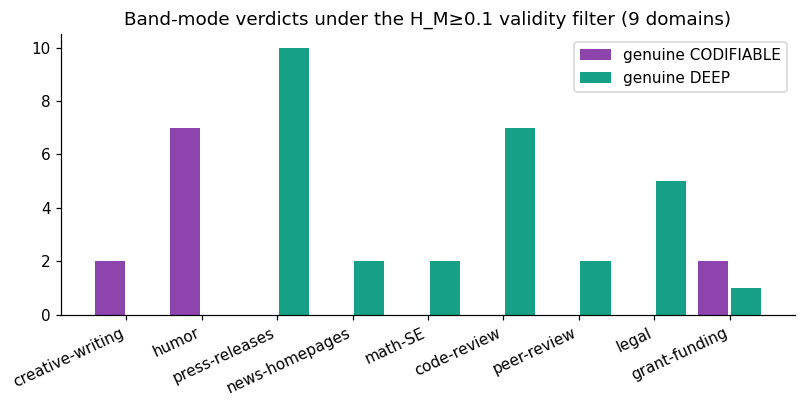

scope-degenerate per domain: {'creative-writing': 0, 'humor': 4, 'press-releases': 6, 'news-homepages': 13, 'math-SE': 0, 'code-review': 4, 'peer-review': 4, 'legal': 4, 'grant-funding': 3}


In [8]:
b = json.load(open(D+'band_mode_reread.json'))
doms, cods, deeps, degs = [], [], [], []
for r in b['results']:
    per = r['per_metric']
    doms.append(r['domain'].replace('-stackexchange','-SE').replace('-outcome-prediction',''))
    cods.append(sum(1 for m in per if m['band']=='CODIFIABLE' and m['H_M']>=0.1))
    deeps.append(sum(1 for m in per if m['band']=='DEEP' and m['H_M']>=0.1))
    degs.append(sum(1 for m in per if m['H_M']<0.1))
x = np.arange(len(doms))
fig, ax = plt.subplots(figsize=(7.5,3.8))
ax.bar(x-0.22, cods, width=.4, label='genuine CODIFIABLE', color='#8e44ad')
ax.bar(x+0.22, deeps, width=.4, label='genuine DEEP', color='#16a085')
ax.set_xticks(x); ax.set_xticklabels(doms, rotation=25, ha='right')
ax.set_title('Band-mode verdicts under the H_M≥0.1 validity filter (9 domains)')
ax.legend(); plt.tight_layout(); plt.show()
print('scope-degenerate per domain:', dict(zip(doms, degs)))

**How to read this figure.** Each domain has two bars: purple = count of genuine CODIFIABLE metrics (short checklist suffices); teal = count of genuine DEEP metrics (heavy tail, many criteria). The H_M ≥ 0.1 filter excludes scope-degenerate criteria (printed below the plot).

**Takeaway:** The codifiable/deep split inverts by domain type — expressive domains certify CODIFIABLE, institutional domains certify DEEP.


## 7. Cross-family replication (in flight) and roadmap

- **Qwen2.5 reader ladder (1.5B/3B/7B)** re-scores the *identical* rung messages for CW and math
  — tests whether definition-peak and the math name-inversion are properties of the articulations
  or of the Llama family. First pass hit a reader-engine teardown race (empty CW report caught by
  a size-checking success gate); re-running one-reader-per-process now.
- **gemma-2 ladder** downloading as a third replication family; **Gemma-4-31B** cached as the
  Stage-D family-top anchor for iso-performance chains.
- **grant×peer transport** unlocks when the repaired grant grid lands (probe-window bug fixed).
- Remaining expansion: notice-and-comment has a rich R2 (88 groups) but a collapsed R3 (5) —
  needs an R3 re-merge before joining the matrix; patents' bank is genuinely thin (7 R2 groups).
- GEPA rung (#14) on the 34 band-DEEP metrics; iso-performance chain v2 stratified by concept
  type (#9); 70B full-native rescore lands ~Jul 10 and upgrades all 70B-reader numbers.

## 8. Tacit-knowledge scaling, cross-family enculturation, a-priori prediction (2026-07-05 pm)

Three follow-up directions added mid-day (tasks #21–23; detailed notes in `2026-07-05__tacit-scaling-enculturation-apriori.md`).

**Instrument note first:** The grid report's `bal_acc` (balanced accuracy) thresholds reader scores at an *absolute* 0.5, which conflates the reader's calibration (how well it converts beliefs to probabilities) with its signal (how well it distinguishes texts). Example failure mode: Qwen2.5-3B scored exactly 0.5 on all 21 math metrics — it was globally under-confident, predicting P(yes) < 0.5 for everything, which collapses to all-negative predictions at the 0.5 threshold — yet its rank signal is healthy (AUC .649).

Everything below therefore uses **threshold-free AUC** (area under ROC curve) **vs the executor's verdicts** — a measure of cross-executor *transmission* (how much of the executor's verdict pattern the reader recovers), deliberately distinct from the census `self_bits` readout used in section 5.

**Definitions:**

- **name-deficit** d = AUC(definition) − AUC(name) — how much gain you get from unpacking the name
- **name-sufficient** = name-AUC ≥ .55 **and** d ≤ ε (the conjunction matters: near the floor, def ≈ name ≈ chance makes d ≤ 0 a coin flip, not a signal)
- **S*** = smallest ladder scale where name-sufficiency holds and persists up-ladder
- The Llama ladder is **1B → 3B → 8B**, with **8B = the executor itself** (self-recovery)


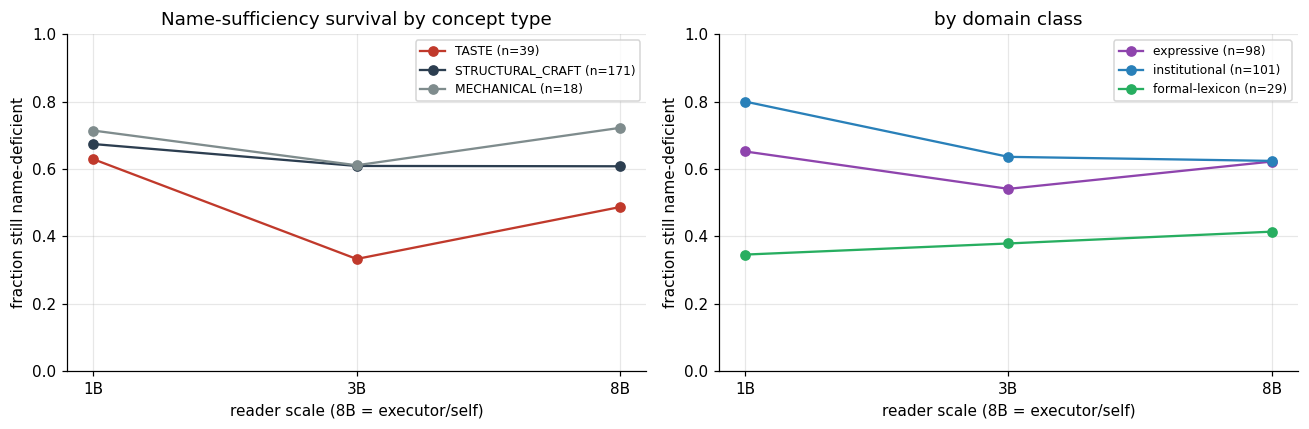

def−name AUC gap at 3B (lexicalization gradient, transmission scale):
  peer   +0.044
  pr     +0.031
  cr     +0.025
  grant  +0.020
  humor  +0.020
  cw     -0.000
  math   -0.023
  legal  -0.051
  news   -0.078


In [9]:
import json, numpy as np, matplotlib.pyplot as plt
D = 'data/two_faces_20260702'
S = json.load(open(f'{D}/name_sufficiency_scaling.json'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sizes = ['1B', '3B', '8B']
for ax, grp, keys, colors in [
        (axes[0], 'by_tag', ['TASTE', 'STRUCTURAL_CRAFT', 'MECHANICAL'], ['#c0392b', '#2c3e50', '#7f8c8d']),
        (axes[1], 'by_class', ['expressive', 'institutional', 'formal-lexicon'], ['#8e44ad', '#2980b9', '#27ae60'])]:
    for k, c in zip(keys, colors):
        v = S['survival'][grp][k]
        fr = [v[s]['frac'] for s in sizes]
        ns = [v[s]['n'] for s in sizes]
        ax.plot(sizes, fr, 'o-', color=c, label=f"{k} (n={max(ns)})")
    ax.set_ylabel('fraction still name-deficient'); ax.set_ylim(0, 1)
    ax.legend(fontsize=8); ax.grid(alpha=.3)
    ax.set_xlabel('reader scale (8B = executor/self)')
axes[0].set_title('Name-sufficiency survival by concept type')
axes[1].set_title('by domain class')
plt.tight_layout(); plt.show()

g = S['gradient_auc'] if 'gradient_auc' in S else S['gradient_bal_acc']
print('def−name AUC gap at 3B (lexicalization gradient, transmission scale):')
for d, v in sorted(g.items(), key=lambda kv: -kv[1].get('3B', 0)):
    print(f"  {d:6s} {v.get('3B', float('nan')):+.3f}")

**Reading §8a:** a three-way dissociation. **Taste names come online between 1B and 3B**
(deficiency .63 → .33) — enculturated indices are cheap once the culture is absorbed. **Craft stays
articulation-dependent at every scale** (~.61 flat through 8B): even the executor itself transmits
craft criteria better through a definition than through the name. **Mechanical names never suffice**
(.71/.61/.72) — "copy-editing" the *word* doesn't carry the spec; codified ≠ lexicalized, inverting the
naive expectation that the most codified criteria should be the most name-transmissible. The
lexicalization gradient of §5 replicates on the transmission scale (formal-lexicon domains negative =
name-peaked). A preregistered ordinal 70B prediction is frozen (`prereg_70b_name_sufficiency.json`,
sha `62e4b3f0…`): 92 metrics predicted to persist + 136 ranked by 8B deficit, flip-set predicted to be
a prefix — to be evaluated with a 70B reader pass after the ~Jul 10 rescore.

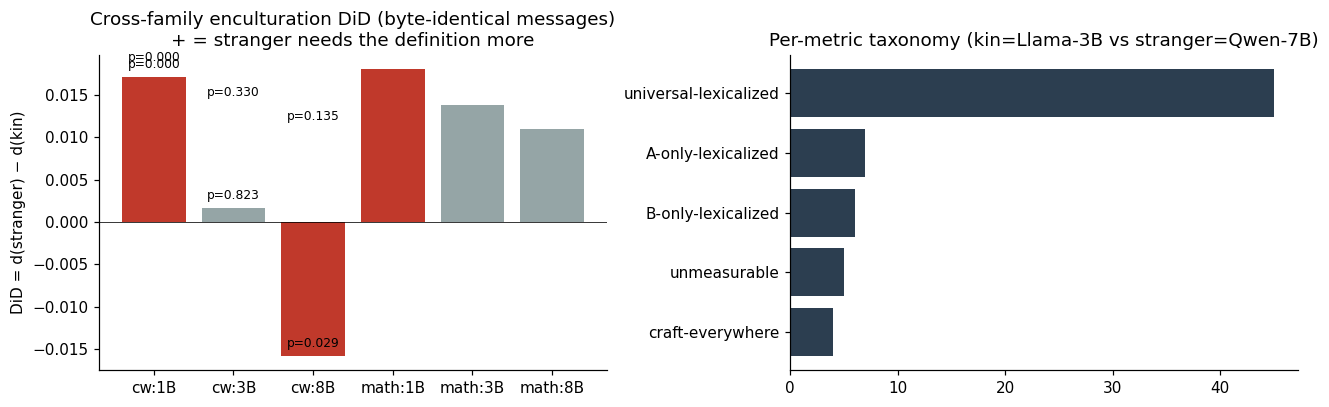

A-ONLY (cw): Pacing and rhythm control  [tag=TASTE]  d_kin=-0.009  d_stranger=+0.024
A-ONLY (cw): Core conflict, goals, and stakes: clarity and escalation  [tag=STRUCTURAL_CRAFT]  d_kin=+0.015  d_stranger=+0.028
A-ONLY (cw): Short/flash fiction craft: compression and resonance  [tag=STRUCTURAL_CRAFT]  d_kin=+0.009  d_stranger=+0.069
A-ONLY (cw): Audience clarity, respect, and accessibility  [tag=STRUCTURAL_CRAFT]  d_kin=+0.017  d_stranger=+0.049
A-ONLY (cw): Opening effectiveness: hook, orientation, and promise alignm  [tag=STRUCTURAL_CRAFT]  d_kin=-0.008  d_stranger=+0.025
A-ONLY (math): Elegance and beauty of proofs  [tag=TASTE]  d_kin=-0.061  d_stranger=+0.038
A-ONLY (math): Notation and terminology: clarity, consistency, naming, and   [tag=STRUCTURAL_CRAFT]  d_kin=-0.002  d_stranger=+0.023


In [10]:
F = json.load(open(f'{D}/family_enculturation.json'))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for dom, r in F.items():
    tiers = [t for t in ['1B', '3B', '8B'] if r['tiers'][t]['mean_DiD'] is not None]
    vals = [r['tiers'][t]['mean_DiD'] for t in tiers]
    ps = [r['tiers'][t]['p_signflip'] for t in tiers]
    axes[0].bar([f"{dom}:{t}" for t in tiers], vals,
                color=['#c0392b' if (p is not None and p < .05) else '#95a5a6' for p in ps])
    for i, (v, p) in enumerate(zip(vals, ps)):
        axes[0].text(i, v + .001, f"p={p:.3f}" if p is not None else '', ha='center', fontsize=8)
axes[0].axhline(0, color='k', lw=.5)
axes[0].set_ylabel('DiD = d(stranger) − d(kin)')
axes[0].set_title('Cross-family enculturation DiD (byte-identical messages)\n+ = stranger needs the definition more')

cats = {}
for dom, r in F.items():
    for c, n in r['taxonomy_counts'].items():
        cats[c] = cats.get(c, 0) + n
order = sorted(cats, key=cats.get)
axes[1].barh(order, [cats[c] for c in order], color='#2c3e50')
axes[1].set_title('Per-metric taxonomy (kin=Llama-3B vs stranger=Qwen-7B)')
plt.tight_layout(); plt.show()

for dom, r in F.items():
    for e in r['taxonomy']:
        if e['cat'] == 'A-only-lexicalized':
            print(f"A-ONLY ({dom}): {e['name'][:60]}  [tag={e['tag']}]  "
                  f"d_kin={e['d_kin_3B']:+.3f}  d_stranger={e['d_stranger_7B']:+.3f}")

**Reading §8b (both pole domains):** the 1B-tier DiD **replicates across domains** (math +.018
p<1e-4; CW +.017 p=.0001): at the smallest size-matched tier, the stranger family needs the definition
more than the kin, on byte-identical messages. The taxonomy separates the two poles: **math's formal
lexicon is family-invariant** (17/21 universal; 2 A-only — flagship *"Elegance and beauty of proofs"*,
the bank's TASTE metric, whose name beats its own definition for the kin, d=−.061, while the stranger
needs the definition, +.038; 0 B-only), whereas **CW's expressive lexicon is family-VARIANT and
bidirectional**: 5 A-only (pacing/rhythm, flash-fiction compression, opening hooks, core-conflict
stakes, audience clarity) AND 6 B-only (macro plot structure, POV control, genre conventions, sustained
tension, setting-as-force, pitch/query) — each family enculturated its own partial inventory, dialects
of craft culture. Family-specific lexicalization rate: CW 27% of measurable metrics vs math 11%.
Caveats: individual cells sit near the ε=.02 boundary (se≈.03-.04) — counts, not cell identities, are
the robust layer; the CW 8B-tier sign flip (−.016, p=.03) is on the SELF-recovery tier (the executor
gains from its own definitions) and is not read as "the stranger knows CW better"; sign-flip tests
treat metrics as independent though they share probes (probe-clustered bootstrap = hardening);
gemma-2 third-family triangulation next.

In [11]:
A = json.load(open(f'{D}/apriori_tacitness_lodo.json'))
print(f"A-priori prediction, leave-one-domain-out (n={A['n']} metrics, outcome = mean 1B+3B name-deficit, AUC scale)")
for fs, r in A['feature_sets'].items():
    print(f"  {fs:16s} spearman={r['lodo_spearman_name_deficit_3B']:+.3f} (p={r['p']})   "
          f"AUC(best-rung=name)={r['lodo_auc_best_rung_is_name']}")
GP = json.load(open(f'{D}/crosstask/grant_peer_isomorphism.json'))
print(f"\nGrant×peer transport (repaired grid): {GP['label_agree']}/{GP['n_scored_labels']} label agreement, "
      f"p_perm={GP['p_perm_bankB_labels']} (marginals A={GP['marginals_a']}, B bank={GP['marginals_b_bank']})")
for p in GP['profiles']:
    print(f"   {p['label_a']}~{p['label_b']}: {p['name_a'][:42]} <-> {p['name_b'][:42]}")

A-priori prediction, leave-one-domain-out (n=227 metrics, outcome = mean 1B+3B name-deficit, AUC scale)
  tags_only        spearman=-0.186 (p=0.00492)   AUC(best-rung=name)=0.439
  tags+class       spearman=-0.065 (p=0.32657)   AUC(best-rung=name)=0.538
  tags+class+lex   spearman=-0.073 (p=0.27657)   AUC(best-rung=name)=0.504

Grant×peer transport (repaired grid): 5/5 label agreement, p_perm=0.0832 (marginals A={'STRUCTURAL_CRAFT': 3, 'MECHANICAL': 2}, B bank={'STRUCTURAL_CRAFT': 7, 'TASTE': 1, 'MECHANICAL': 5})
   STRUCTURAL_CRAFT~STRUCTURAL_CRAFT: Writing clarity, organization, and concisi <-> Writing clarity, organization, and audienc
   MECHANICAL~MECHANICAL: Copy‑editing and mechanical correctness <-> English language correctness and readabili
   STRUCTURAL_CRAFT~STRUCTURAL_CRAFT: Reviewer‑friendly structure and skimmabili <-> Writing clarity, organization, and audienc
   MECHANICAL~MECHANICAL: Responsiveness to solicitation scope, prio <-> Venue/track scope and submission‑type f

**Reading §8c:** the a-priori question ("can metric text predict tacitness load across tasks?")
gets an *instructive null* at first pass: on the calibration-free scale, tags+class+lexical features do
not transfer (ρ≈−.07 n.s.), and concept-type tags alone significantly **anti-predict** (ρ=−.19,
p=.005) — the pooled type→tacitness relation reverses out-of-domain, i.e. **tacitness load is
domain-contextual, not intrinsic to concept type**. (An earlier bal_acc-scale pass showed ρ=.35 — that
was calibration structure, an object lesson in instrument choice.) Scoped next: within-held-out-domain
evaluation, probe split-half reliability ceiling, LM zero-shot predicted-articulability baseline, and
domain-*level* prediction tested on wave-3 domains. **Grant×peer transport** (unlocked by the repaired
grid) lands at 5/5, p_perm=.083 — the first *powered* rigor-family test (mixed marginals, first two
MECHANICAL transports); pooled label transport across 4 pairs: **41/46**.